# Detecção de Objetos Não Explodidos (UXO) — Pipeline de Tratamento de Dados

**Objetivo:** Limpar, tratar e reduzir dimensionalidade do dataset extraído de imagens de sonar,  
preparando os dados para modelos de **Regressão Logística** e **Árvore de Decisão**.

---
| Etapa | Descrição |
|-------|-----------|
| 1 | Carregamento e inspeção inicial |
| 2 | Limpeza: nulos, duplicatas, variância zero |
| 3 | Análise exploratória (EDA) |
| 4 | Normalização / Auto-escalonamento |
| 5 | Seleção de features (correlação + PCA) |
| 6 | Export do dataset tratado |
---

## 0 — Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1 — Carregamento e Inspeção Inicial

In [2]:
DATASET_PATH = r'C:\Users\Usuário\Documents\paradigmas-programacao\testeRegressaoLinear\sonar_tratado.csv'

df = pd.read_csv(DATASET_PATH)

print(f'Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Variável alvo (label): {df["label"].value_counts().to_dict()}')
print(f'→ 0 = Sem mina  |  1 = Mina presente')
df.head()

Dimensões do dataset: 1534 linhas × 454 colunas
Variável alvo (label): {0: 1303, 1: 231}
→ 0 = Sem mina  |  1 = Mina presente


,img_width,img_height,n_annotations,has_milco,has_nombo,mean,std,min,max,p10,...,obj_roi_std,obj_roi_min,obj_roi_max,obj_roi_skewness,obj_roi_energy,obj_highlight_ratio,obj_local_contrast,obj_area_pixels,obj_aspect_ratio,label
0,416,416,0,0,0,49.274345,26.839087,0,198,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1024,1024,0,0,0,49.597939,34.065369,0,236,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,416,416,0,0,0,48.943604,27.324316,0,205,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1024,1024,0,0,0,49.273319,34.182899,0,235,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,416,416,0,0,0,48.341351,27.878534,0,203,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
feature_groups = {
    'Metadados da Imagem': [c for c in df.columns if c.startswith(('img_', 'n_ann', 'has_'))],
    'Estatísticas Globais': [c for c in df.columns if c in
                             ['mean','std','min','max','p10','p25','p50','p75','p90',
                              'skewness','kurtosis','iqr','energy']],
    'HOG (Histograma de Gradientes)': [c for c in df.columns if c.startswith('hog_')],
    'Histograma de Intensidade':      [c for c in df.columns if c.startswith('hist_')],
    'Grid Espacial':                  [c for c in df.columns if c.startswith('grid_')],
    'GLCM (Textura)':                 [c for c in df.columns if c.startswith('glcm_')],
    'Canal de Cor':                   [c for c in df.columns if c.startswith('ch_')],
    'FFT (Frequência)':               [c for c in df.columns if c.startswith('fft_')],
    'Gradientes (Sobel/Laplacian)':   [c for c in df.columns if c.startswith(('sobel_','laplacian_'))],
    'ROI do Objeto':                  [c for c in df.columns if c.startswith(('obj_','ann_'))],
}

print('Grupos de features e suas quantidades:\n')
total = 0
for grupo, cols in feature_groups.items():
    print(f'   {grupo:40s}: {len(cols):3d} colunas')
    total += len(cols)
print(f'   {"label":40s}:   1 coluna')
print(f'   {"TOTAL":40s}: {total+1:3d} colunas')

Grupos de features e suas quantidades:

   Metadados da Imagem                     :   5 colunas
   Estatísticas Globais                    :  13 colunas
   HOG (Histograma de Gradientes)          : 324 colunas
   Histograma de Intensidade               :  32 colunas
   Grid Espacial                           :  32 colunas
   GLCM (Textura)                          :  12 colunas
   Canal de Cor                            :   9 colunas
   FFT (Frequência)                        :   4 colunas
   Gradientes (Sobel/Laplacian)            :   6 colunas
   ROI do Objeto                           :  16 colunas
   label                                   :   1 coluna
   TOTAL                                   : 454 colunas


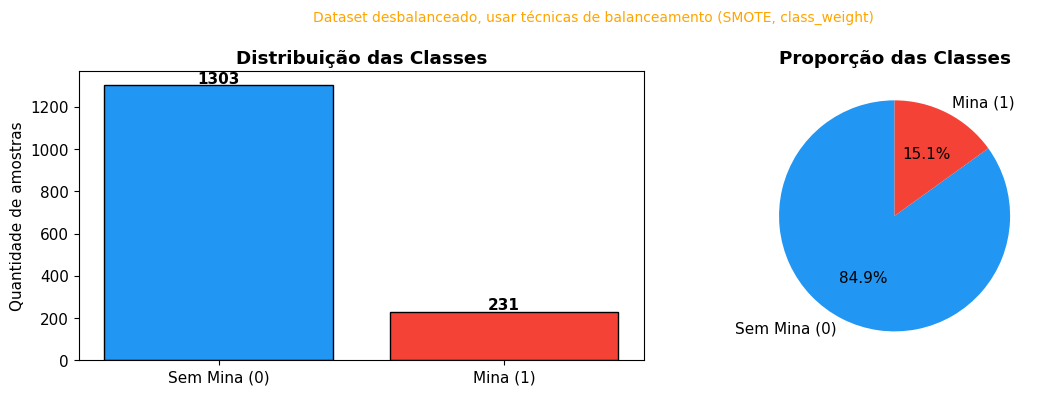


Razão de desbalanceamento: 5.6:1 (Sem Mina : Mina)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
labels_map = {0: 'Sem Mina (0)', 1: 'Mina (1)'}

# Gráfico de colunas para eu ver o desbalanceamento
axes[0].bar([labels_map[k] for k in counts.index], counts.values,
            color=['#2196F3','#F44336'], edgecolor='black')
axes[0].set_title('Distribuição das Classes', fontweight='bold')
axes[0].set_ylabel('Quantidade de amostras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfico de pizza para ficar mais gritante a diferença
axes[1].pie(counts.values, labels=[labels_map[k] for k in counts.index],
            colors=['#2196F3','#F44336'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Dataset desbalanceado, usar técnicas de balanceamento (SMOTE, class_weight)',
             fontsize=10, color='orange')
plt.tight_layout()
plt.show()

print(f'\nRazão de desbalanceamento: {counts[0]/counts[1]:.1f}:1 (Sem Mina : Mina)')

## 2 — Limpeza dos Dados

### 2.1 — Análise de Valores Nulos

In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
null_report = pd.DataFrame({'Nulos': nulos, 'Percentual (%)': nulos_pct})
null_report = null_report[null_report['Nulos'] > 0].sort_values('Percentual (%)', ascending=False)

print(f'Colunas com valores nulos: {len(null_report)} de {df.shape[1]}')
print()
display(null_report)

Colunas com valores nulos: 14 de 454



,Nulos,Percentual (%)
obj_roi_skewness,868,56.58
obj_roi_mean,867,56.52
obj_roi_energy,867,56.52
obj_roi_max,867,56.52
obj_roi_min,867,56.52
obj_roi_std,867,56.52
obj_highlight_ratio,867,56.52
obj_local_contrast,867,56.52
obj_area_pixels,867,56.52
obj_aspect_ratio,867,56.52


In [6]:
# Estratégia para nulos:
# - Colunas com > 50% nulos e que são ROI do objeto: imputar 0 (ausência do objeto)
# - Colunas com poucos nulos: imputar com mediana - (Avaliar se isso faz sentido msm)

LIMIAR_NULO = 50  # % — colunas acima disso recebem tratamento especial

colunas_alto_nulo = null_report[null_report['Percentual (%)'] > LIMIAR_NULO].index.tolist()
colunas_baixo_nulo = null_report[null_report['Percentual (%)'] <= LIMIAR_NULO].index.tolist()

print(f'Colunas com > {LIMIAR_NULO}% nulos (→ imputar 0): {colunas_alto_nulo}')
print(f'\nColunas com < {LIMIAR_NULO}% nulos (→ imputar mediana): {colunas_baixo_nulo}')

Colunas com > 50% nulos (→ imputar 0): ['obj_roi_skewness', 'obj_roi_mean', 'obj_roi_energy', 'obj_roi_max', 'obj_roi_min', 'obj_roi_std', 'obj_highlight_ratio', 'obj_local_contrast', 'obj_area_pixels', 'obj_aspect_ratio', 'ann_w_norm', 'ann_h_norm', 'ann_x_center_norm', 'ann_y_center_norm']

Colunas com < 50% nulos (→ imputar mediana): []


In [7]:
df_clean = df.copy()

# Imputação: ROI sem objeto → 0
df_clean[colunas_alto_nulo] = df_clean[colunas_alto_nulo].fillna(0)

# Ignorando função abaixo pq não temos colunas com menos que 50% nulo

# if colunas_baixo_nulo:
#     for col in colunas_baixo_nulo:
#         df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f'Nulos restantes após tratamento: {df_clean.isnull().sum().sum()}')

Nulos restantes após tratamento: 0


### 2.2 — Remoção de Duplicatas

In [8]:
# Aqui não vou encontrar nada pq não temos linha duplicada nesse dataset

duplicatas = df_clean.duplicated().sum()
print(f'Linhas duplicadas encontradas: {duplicatas}')

if duplicatas > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Duplicatas removidas. Novo shape: {df_clean.shape}')
else:
    print('Nenhuma duplicata encontrada.')

Linhas duplicadas encontradas: 0
Nenhuma duplicata encontrada.


### 2.3 — Remoção de Colunas com Variância Zero ou Constantes

In [9]:
# Separar features e labels antes da análise de variância
X_raw = df_clean.drop(columns=['label'])
y = df_clean['label'].copy()

# Apenas colunas numéricas
X_num = X_raw.select_dtypes(include=[np.number])

# Variância zero
variancia_zero = X_num.columns[X_num.var() == 0].tolist()
print(f'Colunas com variância zero (constantes): {len(variancia_zero)}')
if variancia_zero:
    print(f'   → {variancia_zero}')
    X_num = X_num.drop(columns=variancia_zero)

# Variância muito baixa (quase constante)
LIMIAR_VARIANCIA = 0.01
selector = VarianceThreshold(threshold=LIMIAR_VARIANCIA)
selector.fit(X_num)
cols_baixa_var = X_num.columns[~selector.get_support()].tolist()
print(f'\nColunas com variância < {LIMIAR_VARIANCIA}: {len(cols_baixa_var)}')
if cols_baixa_var:
    X_num = X_num[selector.get_support(indices=False) 
                  if False else X_num.columns[selector.get_support()]]

print(f'\nFeatures restantes após filtro de variância: {X_num.shape[1]}')


# Só de eu filtrar a variancia já reduzimos consideravelmente o dataset

Colunas com variância zero (constantes): 1
   → ['min']

Colunas com variância < 0.01: 368

Features restantes após filtro de variância: 83


### 2.4 — Remoção de Features Não Informativas (Metadados)

In [10]:
# Colunas de metadados que não são features preditivas
# img_width e img_height: apenas tamanho da imagem, não do conteúdo
# n_annotations: dado administrativo, não feature visual
# has_milco / has_nombo: flags de anotação, podem causar data leakage

COLUNAS_PARA_REMOVER = ['img_width', 'img_height', 'n_annotations', 'has_milco', 'has_nombo']
COLUNAS_PARA_REMOVER = [c for c in COLUNAS_PARA_REMOVER if c in X_num.columns]

print(f'Removendo colunas de metadados: {COLUNAS_PARA_REMOVER}')
X_num = X_num.drop(columns=COLUNAS_PARA_REMOVER, errors='ignore')
print(f'Features restantes: {X_num.shape[1]}')

Removendo colunas de metadados: ['img_width', 'img_height', 'n_annotations', 'has_milco', 'has_nombo']
Features restantes: 78


## 3 — Análise Exploratória (EDA)

### 3.1 — Distribuição das Features por Classe

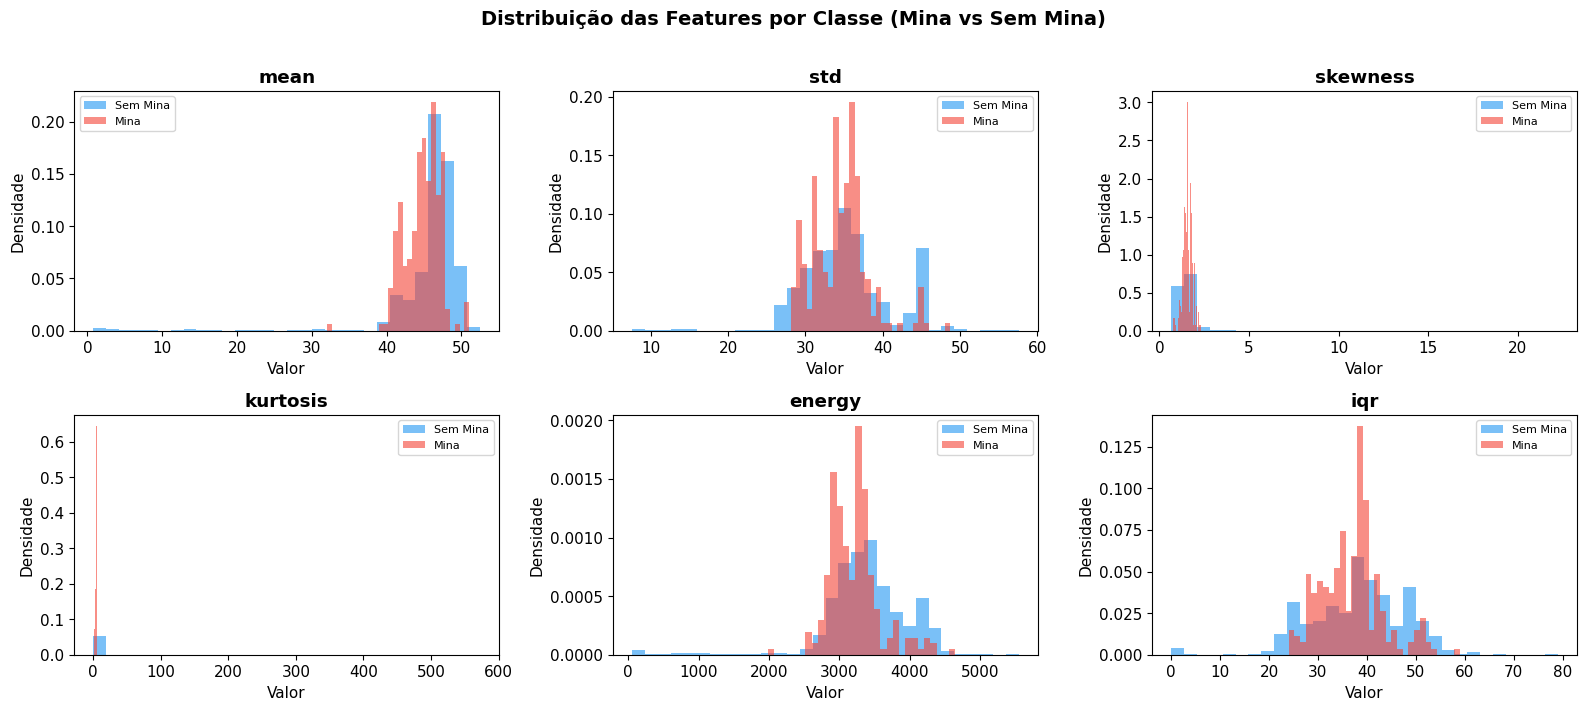

In [11]:
# Features mais importantes para visualização (estatísticas globais)
FEATURES_VISUALIZAR = ['mean', 'std', 'skewness', 'kurtosis', 'energy', 'iqr',
                       'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']
FEATURES_VISUALIZAR = [f for f in FEATURES_VISUALIZAR if f in X_num.columns]

df_eda = X_num[FEATURES_VISUALIZAR].copy()
df_eda['label'] = y.values

n_cols = 3
n_rows = int(np.ceil(len(FEATURES_VISUALIZAR) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURES_VISUALIZAR):
    for label, color, name in [(0, '#2196F3', 'Sem Mina'), (1, '#F44336', 'Mina')]:
        subset = df_eda[df_eda['label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidade')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Features por Classe (Mina vs Sem Mina)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 — Matriz de Correlação (Features Selecionadas)

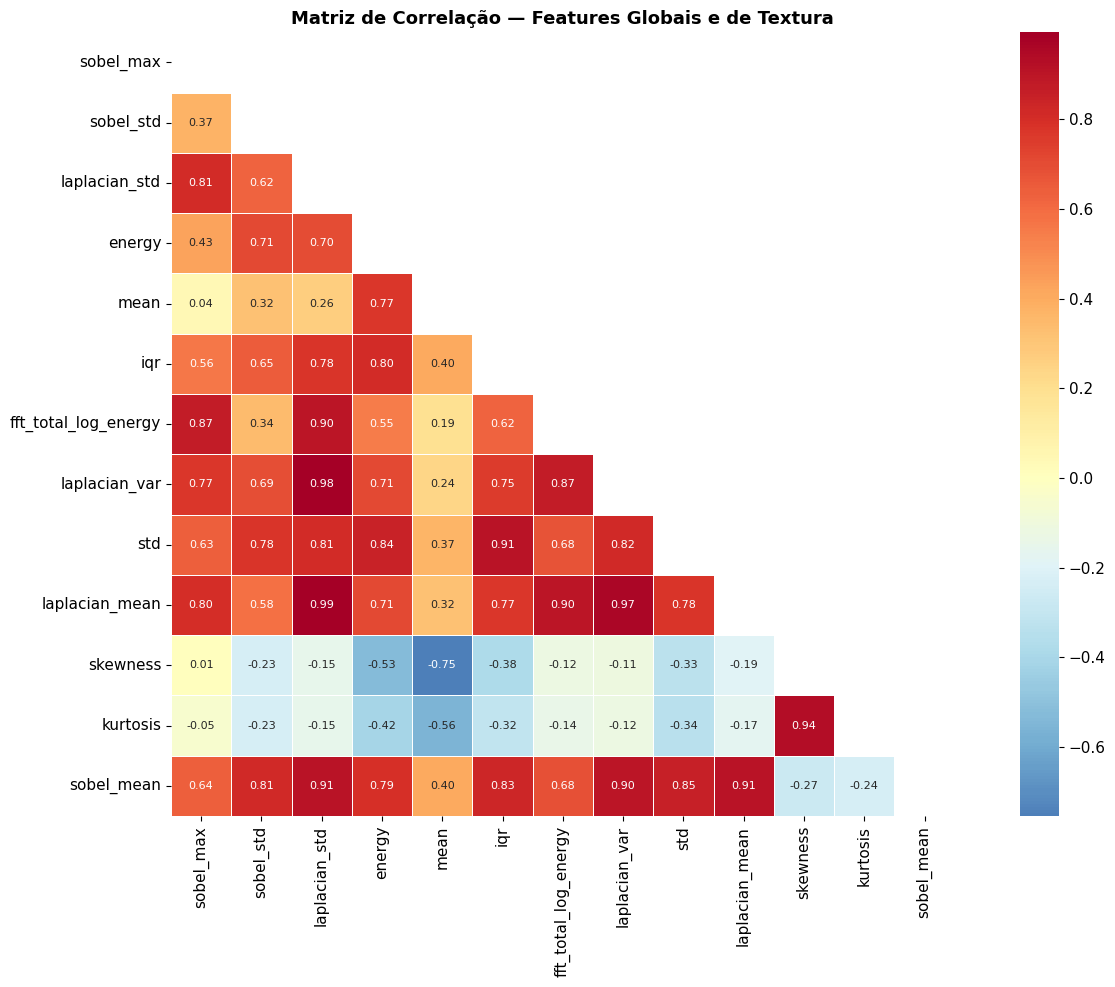

In [12]:
# Analisar correlação nas estatísticas globais + textura (gerenciável em tamanho)
COLUNAS_CORR = FEATURES_VISUALIZAR.copy()

# Adicionar algumas do grid e fft se existirem
extras = [c for c in X_num.columns if c.startswith(('fft_','sobel_','laplacian_'))]
COLUNAS_CORR = list(set(COLUNAS_CORR + extras))
COLUNAS_CORR = [c for c in COLUNAS_CORR if c in X_num.columns]

corr_matrix = X_num[COLUNAS_CORR].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlBu_r', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Matriz de Correlação — Features Globais e de Textura', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Identificar pares de features com alta correlação (possível redundância)
LIMIAR_CORR = 0.90

corr_full = X_num.corr().abs()
upper_tri = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
pares_alta_corr = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > LIMIAR_CORR]

print(f'Pares de features com correlação > {LIMIAR_CORR}: {len(pares_alta_corr)}')

# Features candidatas a remoção por multicolinearidade
features_redundantes = set()
for col1, col2, val in pares_alta_corr:
    features_redundantes.add(col2)  # Remove a segunda de cada par

print(f'Features redundantes identificadas: {len(features_redundantes)}')
print(f'Features únicas restantes (antes do PCA): {X_num.shape[1] - len(features_redundantes)}')

Pares de features com correlação > 0.9: 60
Features redundantes identificadas: 25
Features únicas restantes (antes do PCA): 53


## 4 — Normalização (Auto-escalonamento)

In [14]:
# Remover features redundantes (alta correlação)
X_filtered = X_num.drop(columns=list(features_redundantes), errors='ignore')
print(f'Shape após remoção de redundantes: {X_filtered.shape}')

# StandardScaler: média 0, desvio padrão 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_filtered.columns, index=X_filtered.index)

print(f'\nAuto-escalonamento aplicado (StandardScaler)')
print(f'   Média das features (deve ser ≈0): {X_scaled_df.mean().mean():.6f}')
print(f'   Desvio padrão das features (deve ser ≈1): {X_scaled_df.std().mean():.6f}')
X_scaled_df.head(3)

Shape após remoção de redundantes: (1534, 53)

Auto-escalonamento aplicado (StandardScaler)
   Média das features (deve ser ≈0): 0.000000
   Desvio padrão das features (deve ser ≈1): 1.000326


,max,p10,p25,kurtosis,energy,glcm_dissimilarity_std,glcm_homogeneity_mean,sobel_std,sobel_max,fft_total_log_energy,...,ann_x_center_norm,ann_y_center_norm,obj_roi_min,obj_roi_max,obj_roi_skewness,obj_roi_energy,obj_highlight_ratio,obj_local_contrast,obj_area_pixels,obj_aspect_ratio
0,-2.400697,3.044744,1.890331,-0.033724,-0.384834,0.075096,0.516389,-0.570433,-1.387529,-0.994941,...,-0.680964,-0.718546,-0.34067,-0.846244,-0.673502,-0.606827,-0.640748,-0.498347,-0.217435,-0.732605
1,0.210394,0.261289,0.769702,-0.089993,0.413010,-1.054056,-0.881722,-0.336588,0.667597,0.971250,...,-0.680964,-0.718546,-0.34067,-0.846244,-0.673502,-0.606827,-0.640748,-0.498347,-0.217435,-0.732605
2,-1.919706,3.044744,1.890331,-0.027918,-0.395317,0.111578,0.583199,-0.532323,-1.278734,-0.995977,...,-0.680964,-0.718546,-0.34067,-0.846244,-0.673502,-0.606827,-0.640748,-0.498347,-0.217435,-0.732605


## 5 — Redução de Dimensionalidade com PCA

### 5.1 — Scree Plot: Quantos componentes usar?

   80% da variância explicada com   8 componentes
   90% da variância explicada com  15 componentes
   95% da variância explicada com  22 componentes
   99% da variância explicada com  36 componentes


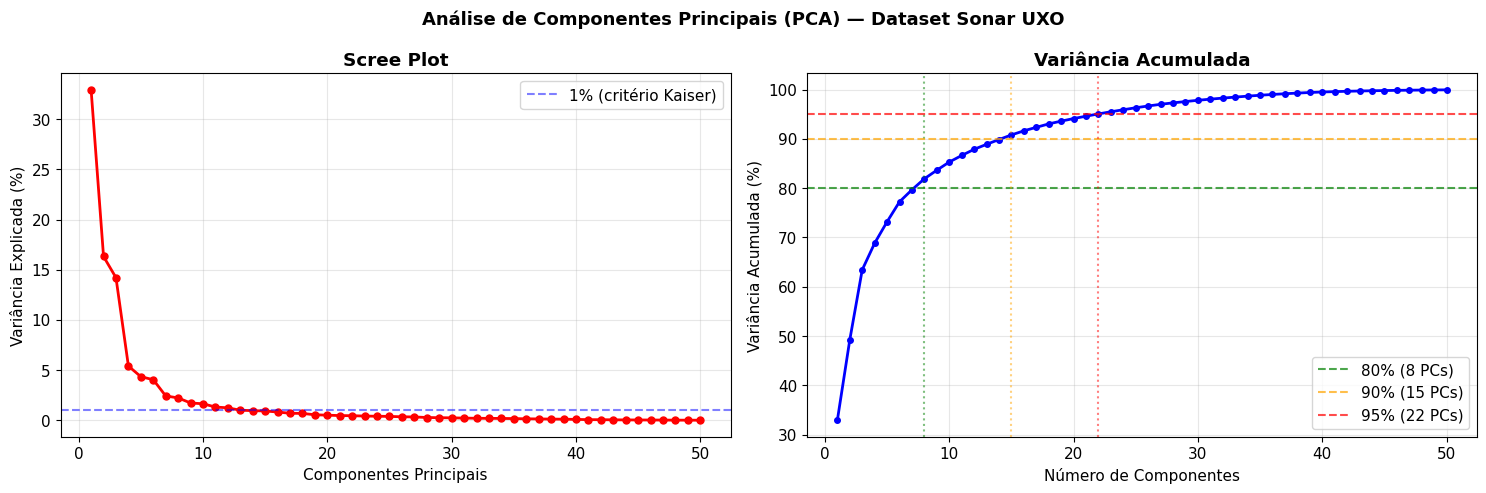

In [15]:
# PCA completo para ver a variância explicada
N_COMP_FULL = min(50, X_scaled_df.shape[1])  # Limita para visualização
pca_full = PCA(n_components=N_COMP_FULL)
pca_full.fit(X_scaled_df)

var_ratio = pca_full.explained_variance_ratio_
var_cum = var_ratio.cumsum()

# Número de componentes para cada limiar
for limiar in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(var_cum >= limiar) + 1
    print(f'   {int(limiar*100)}% da variância explicada com {n:3d} componentes')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].plot(range(1, len(var_ratio)+1), var_ratio * 100, 'ro-', linewidth=2, markersize=5)
axes[0].set_xlabel('Componentes Principais')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].axhline(y=1, color='blue', linestyle='--', alpha=0.5, label='1% (critério Kaiser)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Variância acumulada
axes[1].plot(range(1, len(var_cum)+1), var_cum * 100, 'b-o', linewidth=2, markersize=4)
for limiar, cor in [(80, 'green'), (90, 'orange'), (95, 'red')]:
    n = np.argmax(var_cum >= limiar/100) + 1
    axes[1].axhline(y=limiar, color=cor, linestyle='--', alpha=0.7, label=f'{limiar}% ({n} PCs)')
    axes[1].axvline(x=n, color=cor, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Acumulada', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análise de Componentes Principais (PCA) — Dataset Sonar UXO', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 — Aplicação do PCA com Número Ideal de Componentes

In [16]:
# Definir aqui a variância
VARIANCIA_ALVO = 0.95

N_COMPONENTES = int(np.argmax(var_cum >= VARIANCIA_ALVO)) + 1
print(f'Usando {N_COMPONENTES} componentes para explicar {VARIANCIA_ALVO*100:.0f}% da variância')

pca = PCA(n_components=N_COMPONENTES)
X_pca = pca.fit_transform(X_scaled_df)

col_names = [f'PC{i+1}' for i in range(N_COMPONENTES)]
X_pca_df = pd.DataFrame(X_pca, columns=col_names, index=X_scaled_df.index)

print(f'\nShape final após PCA: {X_pca_df.shape}')
print(f'Redução: {X_num.shape[1]} → {N_COMPONENTES} features ({(1 - N_COMPONENTES/X_num.shape[1])*100:.1f}% de compressão)')
X_pca_df.head(3)

Usando 22 componentes para explicar 95% da variância

Shape final após PCA: (1534, 22)
Redução: 78 → 22 features (71.8% de compressão)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
0,-2.038675,6.676055,-0.710749,0.527484,-0.093916,-0.465572,-0.203055,-0.469003,-0.283768,1.407210,...,-0.538084,-0.412014,-0.505633,0.529430,-0.663413,-0.356119,-0.463880,0.175092,-0.424411,-0.362964
1,1.715479,2.147281,-1.808882,1.199814,-1.550387,-1.391381,0.078684,-1.010128,-0.331094,0.531062,...,0.335152,0.210717,-0.144635,-0.014835,-0.219957,0.000575,0.058907,-0.035721,0.166862,0.030271
2,-1.971805,6.172167,-0.459409,-0.013397,-0.183704,-0.510791,-0.179528,-0.604994,-0.232975,1.284344,...,-0.759087,-0.240531,-0.687464,0.556486,0.071307,-0.604781,-0.463496,0.269669,-0.484553,-0.438719


### 5.3 — Visualização 2D: PC1 vs PC2

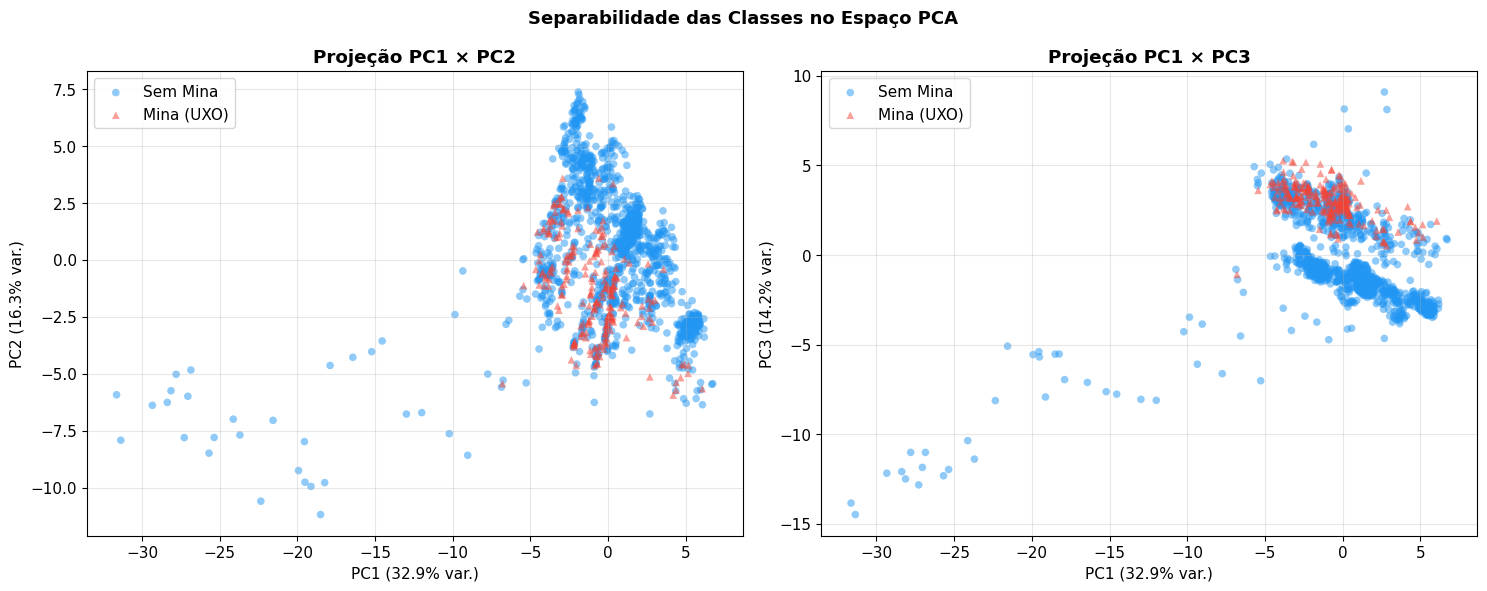

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {0: '#2196F3', 1: '#F44336'}
labels_map = {0: 'Sem Mina', 1: 'Mina (UXO)'}
markers = {0: 'o', 1: '^'}

# Scatter PC1 x PC2
for label in [0, 1]:
    mask = y.values == label
    axes[0].scatter(X_pca_df.loc[mask, 'PC1'], X_pca_df.loc[mask, 'PC2'],
                    c=colors[label], label=labels_map[label],
                    alpha=0.5, s=30, marker=markers[label], edgecolors='none')
axes[0].set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% var.)')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% var.)')
axes[0].set_title('Projeção PC1 × PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter PC1 x PC3 (se existir)
if N_COMPONENTES >= 3:
    for label in [0, 1]:
        mask = y.values == label
        axes[1].scatter(X_pca_df.loc[mask, 'PC1'], X_pca_df.loc[mask, 'PC3'],
                        c=colors[label], label=labels_map[label],
                        alpha=0.5, s=30, marker=markers[label], edgecolors='none')
    axes[1].set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% var.)')
    axes[1].set_ylabel(f'PC3 ({var_ratio[2]*100:.1f}% var.)')
    axes[1].set_title('Projeção PC1 × PC3', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.suptitle('Separabilidade das Classes no Espaço PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 — Contribuição das Features Originais nos Componentes

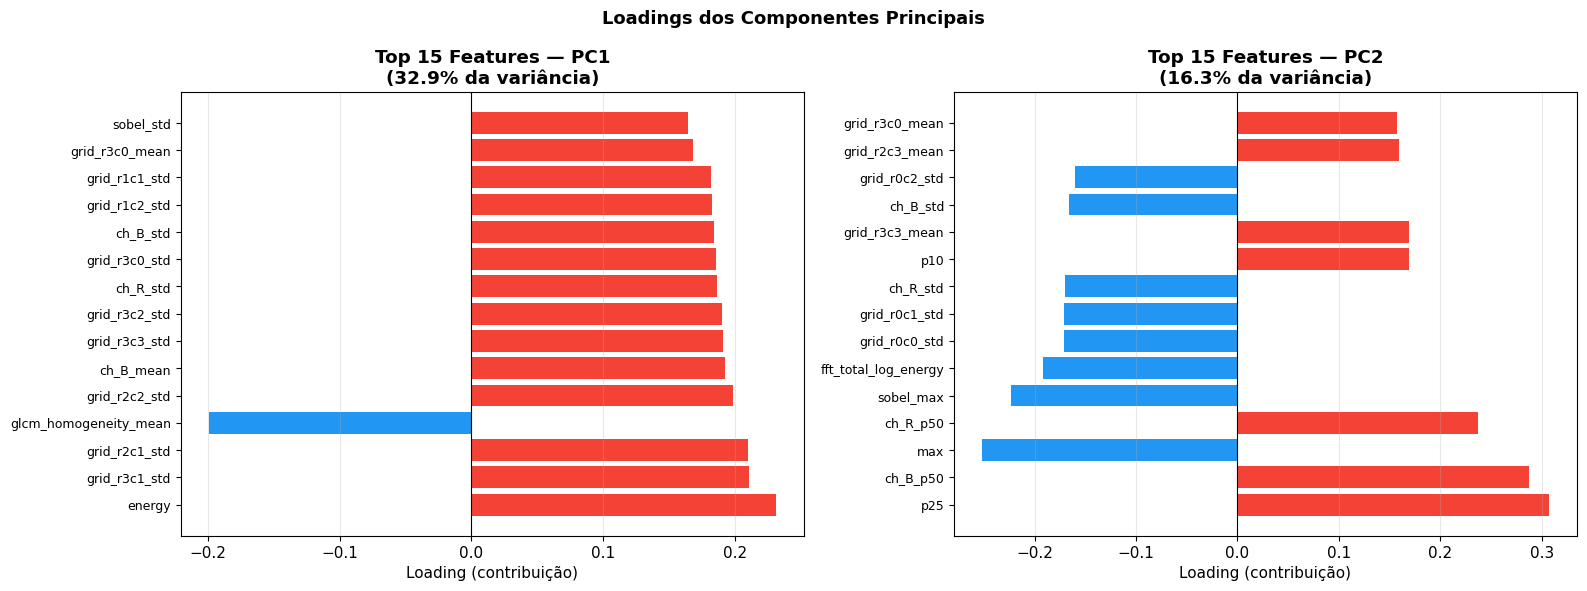

In [18]:
# Top features que mais contribuem para PC1 e PC2
N_TOP = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (ax, pc_idx) in enumerate(zip(axes, [0, 1])):
    loadings = pd.Series(pca.components_[pc_idx], index=X_scaled_df.columns)
    top = loadings.abs().nlargest(N_TOP)
    vals = loadings[top.index]
    
    bars = ax.barh(range(len(vals)), vals.values,
                   color=['#F44336' if v > 0 else '#2196F3' for v in vals.values])
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.set_xlabel('Loading (contribuição)')
    ax.set_title(f'Top {N_TOP} Features — PC{pc_idx+1}\n({var_ratio[pc_idx]*100:.1f}% da variância)',
                 fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Loadings dos Componentes Principais', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Exportação dos Dados Tratados

In [19]:
# Dataset com PCA (para modelos que se beneficiam de descorrelação)
df_pca_final = X_pca_df.copy()
df_pca_final['label'] = y.values

# Dataset sem PCA mas com features limpas e normalizadas (para Árvore de Decisão)
# Árvores de decisão NÃO precisam de normalização, mas podem usar as features originais limpas
df_arvore_final = X_filtered.copy()
df_arvore_final['label'] = y.values

df_pca_final.to_csv('sonar_pca_pronto.csv', index=False)
df_arvore_final.to_csv('sonar_features_limpas.csv', index=False)

print('Arquivos exportados:')
print(f'sonar_pca_pronto.csv       → {df_pca_final.shape} (use para Regressão Logística)')
print(f'sonar_features_limpas.csv  → {df_arvore_final.shape} (use para Árvore de Decisão)')

Arquivos exportados:
sonar_pca_pronto.csv       → (1534, 23) (use para Regressão Logística)
sonar_features_limpas.csv  → (1534, 54) (use para Árvore de Decisão)


## 7 — Resumo do Pipeline

In [20]:
print('=' * 60)
print('RESUMO DO PIPELINE DE TRATAMENTO')
print('=' * 60)
print(f'  Dataset original:          {df.shape[0]} amostras × {df.shape[1]} colunas')
print(f'  Colunas com nulos:         {len(null_report)} → tratadas (0 e mediana)')
print(f'  Duplicatas removidas:      {duplicatas}')
print(f'  Colunas var. zero removidas: {len(variancia_zero)}')
print(f'  Features redundantes (corr>{LIMIAR_CORR}): {len(features_redundantes)}')
print(f'  Metadados removidos:       {len(COLUNAS_PARA_REMOVER)} colunas')
print(f'  Features após limpeza:     {X_filtered.shape[1]}')
print(f'  Normalização:              StandardScaler (média=0, std=1)')
print(f'  PCA: {X_filtered.shape[1]} → {N_COMPONENTES} componentes ({VARIANCIA_ALVO*100:.0f}% variância)')
print()
print('Arquivos de saída:')
print('   sonar_pca_pronto.csv      → Regressão Logística')
print('   sonar_features_limpas.csv → Árvore de Decisão')
print()
print('Importante: dataset desbalanceado (85% sem mina vs 15% mina)')
print('    Considere: class_weight="balanced" ou SMOTE nos modelos futuros')
print('=' * 60)

RESUMO DO PIPELINE DE TRATAMENTO
  Dataset original:          1534 amostras × 454 colunas
  Colunas com nulos:         14 → tratadas (0 e mediana)
  Duplicatas removidas:      0
  Colunas var. zero removidas: 1
  Features redundantes (corr>0.9): 25
  Metadados removidos:       5 colunas
  Features após limpeza:     53
  Normalização:              StandardScaler (média=0, std=1)
  PCA: 53 → 22 componentes (95% variância)

Arquivos de saída:
   sonar_pca_pronto.csv      → Regressão Logística
   sonar_features_limpas.csv → Árvore de Decisão

Importante: dataset desbalanceado (85% sem mina vs 15% mina)
    Considere: class_weight="balanced" ou SMOTE nos modelos futuros
